In [6]:
import numpy as np
import pandas as pd
# Mô phỏng dữ liệu x và y theo một mô hình nào đó sau đó ước lượng mô hình trên dữ liệu tạo ra xem độ chính xác của mô hình ra sao
np.random.seed(123)
#
N = 1000 # tạo ra 1000 quan sát
beta_vec = np.array([-2, 0.5, 0.2]) # Véc tơ hệ số beta1=-2;beta2=0.5;beta3=0.2
#
x1 = np.random.normal(loc = 2, scale = 1, size = N) # Mô phỏng để tạo ra 1000 thể hiện của đại lượng ngẫu nhiên có phân bố chuẩn với kì vọng bằng 1, độ lệch tiêu chuẩn bằng 2
x2 = np.random.normal(loc = 10, scale = 2, size = N)# Mô phỏng để tạo ra 1000 thể hiện của đại lượng ngẫu nhiên có phân bố chuẩn với kì vọng bằng 10, độ lệch tiêu chuẩn bằng 2
#
eta = np.column_stack((np.ones(N), x1, x2)).dot(beta_vec)#eta=X*beta=-2+0.5*x1+0.2x2
prob= 1 / (1 + np.exp(-eta));#Tạo ra một 1000 xác suất =1/(1+exp(-eta))
#
y = np.random.binomial(p = prob, n = 1, size = N)# tạo ra 1000 thể hiện của ĐLNN có phân bố nhị thức với các tham số n=1, p=prob (ở trên) (chính là phân bố Bernouli=Phân bố 0-1)
#
data_mat = pd.DataFrame((y, x1, x2), index = ["y", "x1", "x2"]).T# Tạo ra một bảng dữ liệu 

In [8]:
data_mat.head(20)

,y,x1,x2
0,1.0,0.914369,8.502345
1,1.0,2.997345,11.135189
2,1.0,2.282978,11.436301
3,1.0,0.493705,8.001239
4,1.0,1.421400,10.949797
5,1.0,3.651437,6.263000
6,1.0,-0.426679,9.594682
7,0.0,1.571087,7.731504
8,1.0,3.265936,8.384601
9,1.0,1.133260,7.447845


In [9]:
data_mat1 = pd.DataFrame((y,eta,prob, x1, x2), index = ["y", "eta","prob","x1", "x2"]).T # tạo ra 1 dataframe chứa cột y,eta, prb, x1,x2

In [10]:
data_mat1

,y,eta,prob,x1,x2
0,1.0,0.157654,0.539332,0.914369,8.502345
1,1.0,1.725711,0.848863,2.997345,11.135189
2,1.0,1.428749,0.806706,2.282978,11.436301
3,1.0,-0.152900,0.461849,0.493705,8.001239
4,1.0,0.900659,0.711085,1.421400,10.949797
...,...,...,...,...,...
995,1.0,1.655662,0.839655,2.634763,11.691402
996,1.0,1.086990,0.747815,3.069919,7.760155
997,1.0,0.401618,0.599076,1.090673,9.281407
998,0.0,0.591254,0.643653,2.470264,6.780610


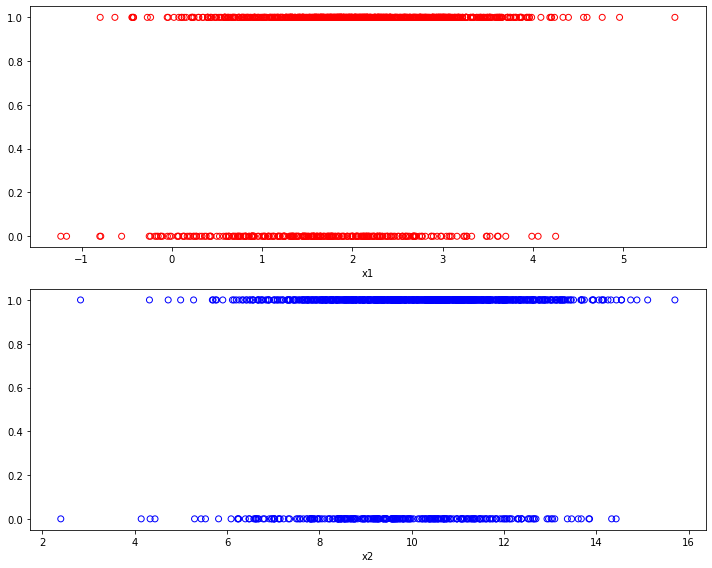

In [11]:
import matplotlib.pyplot as plt
#
fig = plt.figure(figsize = (10, 8))
_ = fig.add_subplot(2, 1, 1).scatter(x1, y, edgecolor = "red", color = "None")
_ = plt.xlabel("x1")
_ = fig.add_subplot(2, 1, 2).scatter(x2, y, edgecolor = "blue", color = "None")
_ = plt.xlabel("x2")
_ = plt.tight_layout()
plt.show()

In [12]:
# Hồi quy tuyến tính của y theo x1 và x2 bằng phương pháp OLS
import statsmodels.formula.api as smf
# Hồi quy OLS y theo x1 và x2
mdl_ols = smf.ols("y ~ 1 + x1 + x2", data = data_mat).fit()
print(mdl_ols.summary2().tables[1])

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


              Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
Intercept  0.174465  0.078411  2.224992  2.630493e-02  0.020594  0.328335
x1         0.108452  0.013679  7.928477  5.919460e-15  0.081609  0.135294
x2         0.033137  0.007145  4.637872  3.988320e-06  0.019116  0.047157


In [13]:
import statsmodels.api as sm 
# Ước lượng mô hình logit 
mdl_glm = smf.glm("y ~ 1 + x1 + x2", data = data_mat, 
              family = sm.families.Binomial(link = sm.genmod.families.links.logit())).fit()
print(mdl_glm.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.877325  0.425286 -4.414263  1.013545e-05 -2.710871 -1.043780
x1         0.577192  0.077278  7.468995  8.080979e-14  0.425729  0.728655
x2         0.177027  0.039164  4.520162  6.179230e-06  0.100267  0.253787


In [14]:
mdl_logit_fit = smf.logit("y ~ 1 + x1 + x2", data = data_mat).fit() # Một cách khác để ước lượng hàm logit

Optimization terminated successfully.
         Current function value: 0.554489
         Iterations 6


In [15]:
print(mdl_logit_fit.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.877325  0.425286 -4.414263  1.013546e-05 -2.710871 -1.043780
x1         0.577192  0.077278  7.468994  8.080996e-14  0.425729  0.728655
x2         0.177027  0.039164  4.520162  6.179234e-06  0.100267  0.253787


In [16]:
# tạo ra các dự báo cho y bằng 2 cách
data_predict = pd.DataFrame(
        [np.linspace(start = data_mat["x1"].min(), stop = data_mat["x1"].max(), num = 500),
         np.linspace(start = data_mat["x2"].min(), stop = data_mat["x2"].max(), num = 500)],
         index = ["x1", "x2"]).T
ols_pred = mdl_ols.predict(exog = data_predict)
glm_pred = mdl_glm.predict(exog = data_predict)

In [17]:
data_predict

,x1,x2
0,-1.231055,2.397244
1,-1.217422,2.423905
2,-1.203790,2.450567
3,-1.190157,2.477229
4,-1.176525,2.503890
...,...,...
495,5.517049,15.594769
496,5.530682,15.621430
497,5.544314,15.648092
498,5.557947,15.674754


In [18]:
data_mat2= pd.DataFrame((ols_pred,glm_pred,prob), index = ["ols_pred", "glm_pred","prob"]).T # tạo ra 1 dataframe chứa cột y,eta, prb, x1,x2

In [19]:
data_mat2.head(20)

,ols_pred,glm_pred,prob
0,0.120391,0.103076,0.539332
1,0.122753,0.104246,0.848863
2,0.125115,0.105427,0.806706
3,0.127477,0.106620,0.461849
4,0.129839,0.107825,0.711085
5,0.132201,0.109042,0.746176
6,0.134563,0.110271,0.426926
7,0.136925,0.111512,0.582208
8,0.139287,0.112766,0.787494
9,0.141649,0.114031,0.514046


In [20]:
x_beta_predict = mdl_glm.predict(exog = data_predict, linear = True)
print(x_beta_predict.head(5))

0   -2.163504
1   -2.150915
2   -2.138327
3   -2.125738
4   -2.113150
dtype: float64


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  if __name__ == '__main__':
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:11: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the

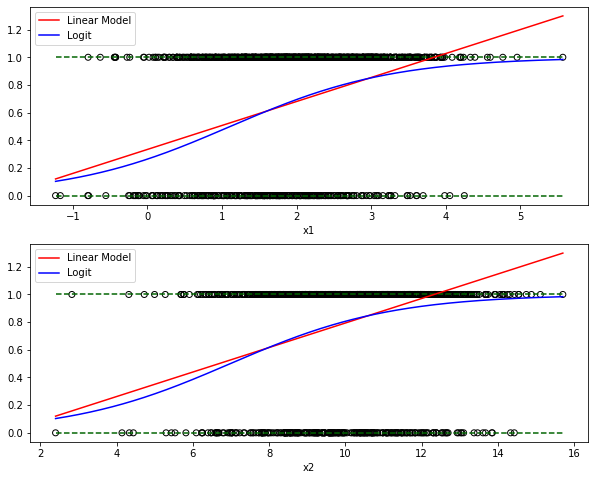

In [21]:
#Vẽ đồ thị thể hàm hồi quy tìm được bằng 2 cách OLS và logit
fig = plt.figure(figsize = (10, 8))
for i in range(0, 2):
  j = ["x1", "x2"][i]
  _ = fig.add_subplot(2, 1, i + 1).scatter(data_mat[j], data_mat["y"], 
    edgecolor = "black", color = "None", label = "_nolegend_")
  _ = fig.add_subplot(2, 1, i + 1).plot(data_predict[j], ols_pred, 
    color = "red", label = "Linear Model")
  _ = fig.add_subplot(2, 1, i + 1).plot(data_predict[j], glm_pred, 
    color = "blue", label = "Logit")
  _ = fig.add_subplot(2, 1, i + 1).hlines(y = [0, 1], 
    linestyles = "dashed", color = "darkgreen", label = "_nolegend_",
    xmin = data_predict[j].min(), xmax = data_predict[j].max())
  _ = plt.xlabel(j)
  _ = plt.legend(loc = "upper left")
plt.show()

In [22]:
mdl_logit_fit = smf.glm("y ~ 1 + x1 + x2", data = data_mat, 
              family = sm.families.Binomial(link = sm.genmod.families.links.logit())).fit()
print(mdl_logit_fit.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.877325  0.425286 -4.414263  1.013545e-05 -2.710871 -1.043780
x1         0.577192  0.077278  7.468995  8.080979e-14  0.425729  0.728655
x2         0.177027  0.039164  4.520162  6.179230e-06  0.100267  0.253787


In [23]:
print(mdl_logit_fit.params / (np.pi / np.sqrt(3)))

Intercept   -1.035024
x1           0.318223
x2           0.097600
dtype: float64


In [24]:
mdl_logit_fit = smf.glm("y ~ 1 + x1 + x2", data = data_mat, 
              family = sm.families.Binomial(link = sm.genmod.families.links.logit())).fit()
print(mdl_logit_fit.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.877325  0.425286 -4.414263  1.013545e-05 -2.710871 -1.043780
x1         0.577192  0.077278  7.468995  8.080979e-14  0.425729  0.728655
x2         0.177027  0.039164  4.520162  6.179230e-06  0.100267  0.253787


In [25]:
mdl_probit_fit = smf.glm("y ~ 1 + x1 + x2", data = data_mat, 
              family = sm.families.Binomial(link = sm.genmod.families.links.probit())).fit()
print(mdl_probit_fit.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -1.118343  0.251822 -4.441007  8.953902e-06 -1.611905 -0.624781
x1         0.346657  0.045182  7.672487  1.686933e-14  0.258102  0.435212
x2         0.106196  0.023067  4.603716  4.150184e-06  0.060985  0.151407


In [26]:
probit_eta = mdl_probit_fit.predict(exog = data_predict, linear = True)
logit_eta  = mdl_logit_fit.predict(exog = data_predict, linear = True)
print(pd.DataFrame([probit_eta, logit_eta], index = ["probit_eta", "logit_eta"]).T.head(6))

   probit_eta  logit_eta
0   -1.290519  -2.163504
1   -1.282962  -2.150915
2   -1.275405  -2.138327
3   -1.267848  -2.125738
4   -1.260290  -2.113150
5   -1.252733  -2.100562


In [27]:
data_predict = pd.DataFrame(
        [np.linspace(start = data_mat["x1"].min(), stop = data_mat["x1"].max(), num = 100),
         np.linspace(start = data_mat["x2"].min(), stop = data_mat["x2"].max(), num = 100)],
         index = ["x1", "x2"]).T
#
xx1, xx2 = np.meshgrid(data_predict["x1"], data_predict["x2"])
exog = pd.core.frame.DataFrame({'x1': xx1.ravel(), 'x2': xx2.ravel()})
#
logit_pred_tmp  = mdl_logit_fit.predict(exog = exog, linear = False)
probit_pred_tmp = mdl_probit_fit.predict(exog = exog, linear = False)

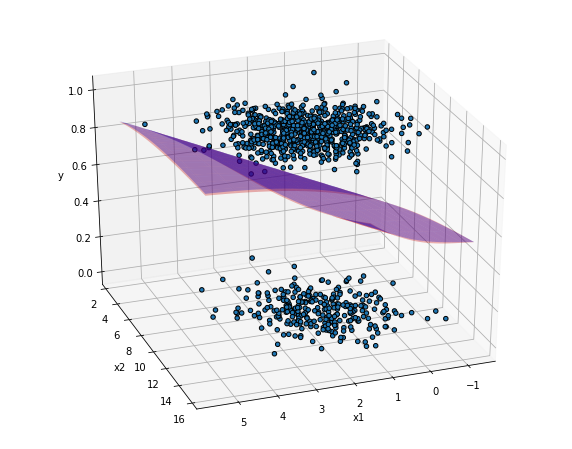

In [28]:
from mpl_toolkits.mplot3d import Axes3D
#
fig = plt.figure(figsize = (10, 8))
ax = fig.gca(projection = '3d')
_ = ax.plot_surface(xx1, xx2, np.reshape(np.array(logit_pred_tmp), xx1.shape), 
                rstride = 8, cstride = 8, color = "red", alpha = 0.3)
_ = ax.plot_surface(xx1, xx2, np.reshape(np.array(probit_pred_tmp), xx1.shape), 
                rstride = 8, cstride = 8, color = "blue", alpha = 0.3)
_ = ax.scatter(data_mat['x1'], data_mat['x2'], data_mat['y'], alpha = 1, edgecolor = "black")
_ = ax.set_xlabel("x1")
_ = ax.set_ylabel("x2")
_ = ax.set_zlabel("y")
_ = ax.view_init(30, 70)
plt.show()

In [29]:
#Đồ thị dạng động
import plotly.offline as py
import plotly.graph_objs as go
#
surface = [go.Surface(x = xx1, y = xx2, z = np.reshape(np.array(logit_pred_tmp), xx1.shape),
                      surfacecolor = np.reshape([0.1] * len(logit_pred_tmp), xx1.shape), 
                      showscale = False, opacity = 0.9, cauto = False, cmax = 1, cmin = 0),
           go.Surface(x = xx1, y = xx2, z = np.reshape(np.array(probit_pred_tmp), xx1.shape),
                      surfacecolor = np.reshape([0.65] * len(probit_pred_tmp), xx1.shape), 
                      showscale = False, cauto = False, cmax = 1, cmin = 0)]
fig = go.Figure(data = surface)
_ = fig.update_layout(width = 500, height = 600)
_ = fig.add_scatter3d(x = data_mat["x1"], y = data_mat["x2"], z = data_mat["y"], 
                mode = 'markers', 
                marker = dict(size = 2, color = [0] * len(data_mat["y"]), colorscale = 'Magma'))
_ = py.plot(fig, filename = "binary_scatter.html", auto_open = True)

In [30]:
fig.show()

In [31]:
mdl_logit_fit = smf.logit("y ~ 1 + x1 + x2", data = data_mat).fit()

Optimization terminated successfully.
         Current function value: 0.554489
         Iterations 6


In [32]:
mdl_probit_fit= smf.probit("y ~ 1 + x1 + x2", data = data_mat).fit()

Optimization terminated successfully.
         Current function value: 0.554021
         Iterations 5


In [33]:
print(mdl_logit_fit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8773      0.425     -4.414      0.000      -2.711      -1.044
x1             0.5772      0.077      7.469      0.000       0.426       0.729
x2             0.1770      0.039      4.520      0.000       0.100       0.254


In [34]:
PEA_logit = mdl_logit_fit.get_margeff(at = "mean")
print(PEA_logit.summary())

        Logit Marginal Effects       
Dep. Variable:                      y
Method:                          dydx
At:                              mean
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1120      0.015      7.668      0.000       0.083       0.141
x2             0.0344      0.008      4.563      0.000       0.020       0.049


In [35]:
# Khi x1 tăng 1 đơn vị thì xác suất p tăng 1 lượng là 0.1120
# Khi x2 tăng 1 đơn vị với đk các yếu tố khác không đổi thi p tăng 1 lượng 0.0344

In [36]:
APE_logit = mdl_logit_fit.get_margeff(at = "overall")
print(APE_logit.summary())

        Logit Marginal Effects       
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1075      0.013      8.240      0.000       0.082       0.133
x2             0.0330      0.007      4.675      0.000       0.019       0.047


In [37]:
print(mdl_probit_fit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1183      0.251     -4.462      0.000      -1.610      -0.627
x1             0.3467      0.045      7.656      0.000       0.258       0.435
x2             0.1062      0.023      4.634      0.000       0.061       0.151


In [38]:
PEA_probit = mdl_probit_fit.get_margeff(at = "mean")
print(PEA_probit.summary())

       Probit Marginal Effects       
Dep. Variable:                      y
Method:                          dydx
At:                              mean
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1138      0.015      7.743      0.000       0.085       0.143
x2             0.0348      0.007      4.654      0.000       0.020       0.050


In [39]:
# Trong mô hình probit khi trung bình x1 tăng 1 đơn vị các yếu tố khác không đổi thì xác suất tăng 1 lượng là 0.1138

In [40]:
APE_probit = mdl_probit_fit.get_margeff(at = "overall")
print(APE_probit.summary())

       Probit Marginal Effects       
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1085      0.013      8.343      0.000       0.083       0.134
x2             0.0332      0.007      4.773      0.000       0.020       0.047


In [41]:
# Trong mô hình probit khi x1 tăng 1 đơn vị các yếu tố khác không đổi thì xác suất tăng 1 lượng là 0.1085

In [42]:
from sklearn import metrics #thư viện để đánh giá độ chính xác của mô hình
#
tmp_pred = mdl_logit_fit.predict(exog = data_mat)
fpr, tpr, thresholds = metrics.roc_curve(data_mat['y'], tmp_pred)
# as per the documentation, thresholds[0] represents no instances being predicted and is arbitrarily set to max(y_score) + 1 - so we need to drop it
thresholds = thresholds[1:]
fpr = fpr[1:]
tpr = tpr[1:]

In [43]:
# Tìm ngưỡng tối ưu để cutoff : Nếu tmp_pred> ngưỡng cho y=1, ngược lại =0
misclasserror = []
for k in thresholds:
  # Transform from probability to binary value based on the threshold
  y_pred = np.where(tmp_pred >= k, 1, 0)
  misclasserror.append(1 - metrics.accuracy_score(data_mat['y'], y_pred))
#
# Let's take the first value, which indicates a lower threshold value
optimalCutoff_logit_1 = thresholds[misclasserror == np.min(misclasserror)][0]
print(optimalCutoff_logit_1)

0.4465344516446204


In [44]:
true_ones = []
for k in thresholds:
  # Transform from probability to binary value based on the threshold
  y_pred = np.where(tmp_pred >= k, 1, 0)
  true_ones.append(metrics.confusion_matrix(data_mat['y'], y_pred)[1, 1])
#
# Let's take the first value, which indicates a lower threshold value
optimalCutoff_logit_2 = thresholds[true_ones == np.max(true_ones)][0]
print(optimalCutoff_logit_2)

0.24857289334537883


In [45]:
true_ones = []
for k in thresholds:
  # Transform from probability to binary value based on the threshold
  y_pred = np.where(tmp_pred >= k, 1, 0)
  true_ones.append(metrics.confusion_matrix(data_mat['y'], y_pred)[0, 0])
#
# Let's take the first value, which indicates a lower threshold value
optimalCutoff_logit_3 = thresholds[true_ones == np.max(true_ones)][0]
print(optimalCutoff_logit_3)

0.9562563699474397


In [46]:
j_scores = tpr - fpr
optimalCutoff_logit_4 = thresholds[j_scores == np.max(j_scores)][0]
print(optimalCutoff_logit_4)

0.7249237838596329


In [47]:
tmp_pred = mdl_probit_fit.predict(exog = data_mat)
fpr, tpr, thresholds = metrics.roc_curve(data_mat['y'], tmp_pred)
#
thresholds = thresholds[1:]
fpr = fpr[1:]
tpr = tpr[1:]

In [48]:
misclasserror = []
for k in thresholds:
  # Transform from probability to binary value based on the threshold
  y_pred = np.where(tmp_pred >= k, 1, 0)
  misclasserror.append(1 - metrics.accuracy_score(data_mat['y'], y_pred))
#
# Let's take the first value, which indicates a lower threshold value
optimalCutoff_probit_1 = thresholds[misclasserror == np.min(misclasserror)][0]
print(optimalCutoff_probit_1)

0.45196209520726255


In [49]:
predicted_probs_logit = mdl_logit_fit.predict(exog = data_mat)
tmp_out = metrics.confusion_matrix(mdl_logit_fit.model.endog, 
                               np.where(predicted_probs_logit >= 0.5, 1, 0))
print(pd.DataFrame(tmp_out, 
                   columns = ["Predicted 0", "Predicted 1"],
                   index = ["Actual 0", "Actual 1"]))

          Predicted 0  Predicted 1
Actual 0           32          249
Actual 1           34          685


In [50]:
tmp_out1 = mdl_logit_fit.pred_table(threshold = 0.5)
print(pd.DataFrame(tmp_out1, columns = ["Predicted 0", "Predicted 1"], index = ["Actual 0", "Actual 1"]))

          Predicted 0  Predicted 1
Actual 0         32.0        249.0
Actual 1         34.0        685.0


In [51]:
predicted_probs_probit = mdl_probit_fit.predict(exog = data_mat)
tmp_out = metrics.confusion_matrix(mdl_probit_fit.model.endog, 
                                   np.where(predicted_probs_probit >= 0.5, 1, 0))
print(pd.DataFrame(tmp_out, 
                   columns = ["Predicted 0", "Predicted 1"],
                   index = ["Actual 0", "Actual 1"]))

          Predicted 0  Predicted 1
Actual 0           32          249
Actual 1           34          685


In [52]:
# import statsmodels as sm
# sm.stats.contingency_tables()
print(data_mat["y"].value_counts())

1.0    719
0.0    281
Name: y, dtype: int64


In [53]:
predicted_probs_logit = mdl_logit_fit.predict(exog = data_mat)
tmp_out = metrics.confusion_matrix(mdl_logit_fit.model.endog, 
                               np.where(predicted_probs_logit >= optimalCutoff_logit_1, 1, 0))
print(pd.DataFrame(tmp_out, 
                   columns = ["Predicted 0", "Predicted 1"],
                   index = ["Actual 0", "Actual 1"])) 

          Predicted 0  Predicted 1
Actual 0           20          261
Actual 1           14          705


In [54]:
predicted_probs_logit = mdl_logit_fit.predict(exog = data_mat)
tmp_out = metrics.confusion_matrix(mdl_logit_fit.model.endog, 
                               np.where(predicted_probs_logit >= optimalCutoff_logit_4, 1, 0))
print(pd.DataFrame(tmp_out, 
                   columns = ["Predicted 0", "Predicted 1"],
                   index = ["Actual 0", "Actual 1"]))

          Predicted 0  Predicted 1
Actual 0          181          100
Actual 1          267          452


In [55]:
predicted_probs_probit = mdl_probit_fit.predict(exog = data_mat)
tmp_out = metrics.confusion_matrix(mdl_probit_fit.model.endog, 
                               np.where(predicted_probs_probit >= optimalCutoff_probit_1, 1, 0))
print(pd.DataFrame(tmp_out, 
                   columns = ["Predicted 0", "Predicted 1"],
                   index = ["Actual 0", "Actual 1"]))

          Predicted 0  Predicted 1
Actual 0           20          261
Actual 1           14          705


In [56]:
tmp_accuracy = metrics.accuracy_score(mdl_logit_fit.model.endog,
                       np.where(predicted_probs_logit >= optimalCutoff_logit_1, 1, 0))
print(tmp_accuracy)                       

0.725


In [57]:
tmp_accuracy = metrics.accuracy_score(mdl_logit_fit.model.endog,
                       np.where(predicted_probs_logit >= optimalCutoff_logit_1, 1, 0))
print(1 - tmp_accuracy) 

0.275


In [58]:
tmp_sensitivity = metrics.recall_score(mdl_logit_fit.model.endog, 
                          np.where(predicted_probs_logit >= optimalCutoff_logit_1, 1, 0))
print(tmp_sensitivity)                         

0.980528511821975


In [59]:
tmp_diagnostics = pd.DataFrame(metrics.precision_recall_fscore_support(mdl_logit_fit.model.endog,
                      np.where(predicted_probs_logit >= optimalCutoff_logit_1, 1, 0)),
                      index = ["precision","recall", "fbeta_score", "support"])
print(tmp_diagnostics)

                      0           1
precision      0.588235    0.729814
recall         0.071174    0.980529
fbeta_score    0.126984    0.836795
support      281.000000  719.000000


In [60]:
print(tmp_diagnostics.iloc[2, 1])

0.8367952522255192


In [61]:
print(metrics.classification_report(mdl_logit_fit.model.endog, 
                          np.where(predicted_probs_logit >= optimalCutoff_logit_1, 1, 0)))

              precision    recall  f1-score   support

         0.0       0.59      0.07      0.13       281
         1.0       0.73      0.98      0.84       719

    accuracy                           0.73      1000
   macro avg       0.66      0.53      0.48      1000
weighted avg       0.69      0.72      0.64      1000



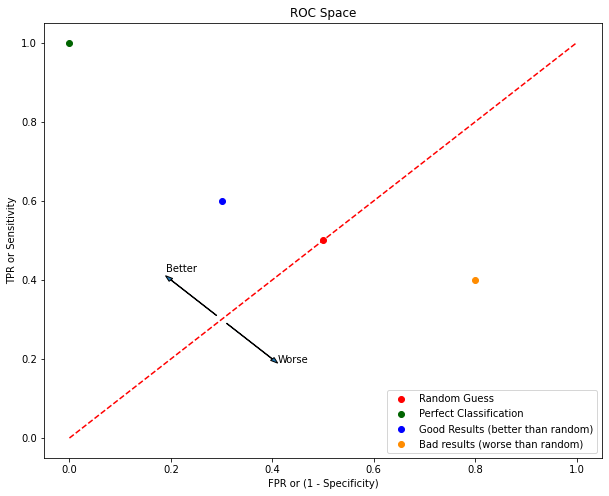

In [68]:
import numpy as np
import matplotlib.pyplot as plt
#
fig = plt.figure(figsize = (10, 8))
_ = plt.plot(np.linspace(start = 0, stop = 1, num = 100), 
             np.linspace(start = 0, stop = 1, num = 100), linestyle = "--", color = "red")
_ = plt.xlabel("FPR or (1 - Specificity)")
_ = plt.ylabel("TPR or Sensitivity")
_ = plt.title("ROC Space")
_ = plt.scatter(0.5, 0.5, color = "red", label = "Random Guess")
_ = plt.scatter(0, 1, color = "darkgreen", label = "Perfect Classification")
_ = plt.scatter(0.3, 0.6, color = "blue", label = "Good Results (better than random)")
_ = plt.scatter(0.8, 0.4, color = "darkorange", label = "Bad results (worse than random)")
_ = plt.arrow(x = 0.29, y = 0.31, dx = -0.09, dy = 0.09, head_width = 0.01)
_ = plt.arrow(x = 0.31, y = 0.29, dx = 0.09, dy = -0.09, head_width = 0.01)
_ = plt.annotate("Better", (0.19,  0.42))
_ = plt.annotate("Worse", (0.41,  0.19))
_ = plt.legend(loc = "lower right")
plt.show()

In [69]:
np.random.seed(12345)
thresholds = np.arange(start = 0.01, stop = 0.99 + 0.01, step = 0.01)
ppred = pd.DataFrame((predicted_probs_logit, 
                      predicted_probs_probit,
                      np.random.uniform(size = int(len(data_mat.index))))).T
TPR = np.empty(shape = (0, 99))
FPR = np.empty(shape = (0, 99))
#
for j in range(0, len(ppred.columns)):
  tpr = np.array([])
  fpr = np.array([])
  for i in thresholds:
    tpr = np.hstack((tpr, 
                  metrics.recall_score(data_mat[["y"]], np.where(ppred[j] >= i, 1, 0))))
    fpr = np.hstack((fpr, 
                  1 - metrics.precision_recall_fscore_support(data_mat[["y"]], np.where(ppred[j] >= i, 1, 0))[1][0]))
  #
  TPR = np.vstack((TPR, tpr))
  FPR = np.vstack((FPR, fpr))
# 
TPR = pd.DataFrame(TPR).T
FPR = pd.DataFrame(FPR).T

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` param

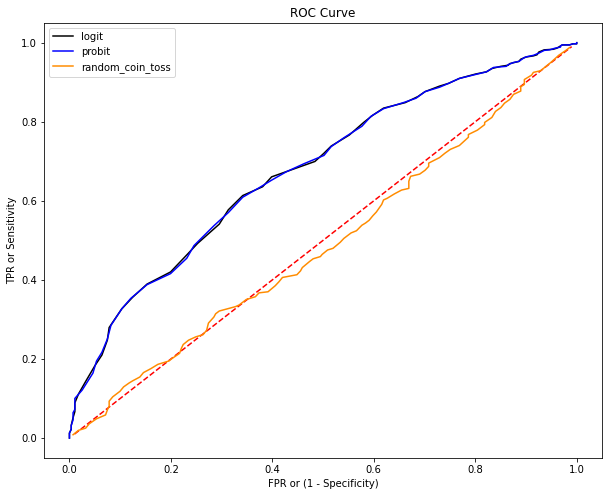

In [64]:
fig = plt.figure(figsize = (10, 8))
_ = plt.plot(thresholds, 
             thresholds, linestyle = "--", color = "red")
_ = plt.xlabel("FPR or (1 - Specificity)")
_ = plt.ylabel("TPR or Sensitivity")
_ = plt.title("ROC Curve")
for j in range(0, len(ppred.columns)):
  _ = plt.plot(FPR[j], TPR[j], linestyle = "-", 
               color = ["black", "blue", "darkorange"][j],
               label = ["logit", "probit", "random_coin_toss"][j])
#
_ = plt.legend(loc = "upper left")               
plt.show()

In [65]:
def plotROC(fpr, tpr, thresholds): 
  #
  roc_auc = metrics.auc(fpr, tpr)
  #
  fig = plt.figure(figsize = (10, 8))
  plt.plot(fpr, tpr, linestyle = "-", color = "cornflowerblue")
  # Fill in the ROC curve
  plt.fill_between(fpr, tpr, 0, color = "cornflowerblue")
  # Add annotations
  plt.annotate(s = "AUROC: " + str(roc_auc.round(4)), xy = (0.3, 0.3), color = "white", fontsize = 25)
  for i in range(1, len(fpr))[::10]:
    _ = plt.annotate(s = thresholds[i].round(2), xy = (fpr[i], tpr[i]))
  #
  plt.xlabel("1-Specificity (FPR)", color = "cornflowerblue", fontsize = 25)
  plt.ylabel("Sensitivity (TPR)", color = "cornflowerblue", fontsize = 25)
  plt.title("ROC Curve", color = "cornflowerblue", fontsize = 25)
  # Setting the background color
  ax = fig.add_subplot(1, 1, 1) 
  ax.set_facecolor("lightgray")
  # Add grid
  plt.grid(True, zorder = 0, color = "white")
  # Make sure the grid is in the background
  plt.rcParams['axes.axisbelow'] = True
  plt.tight_layout()
  plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:18: MatplotlibDeprecationWarning:

Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.



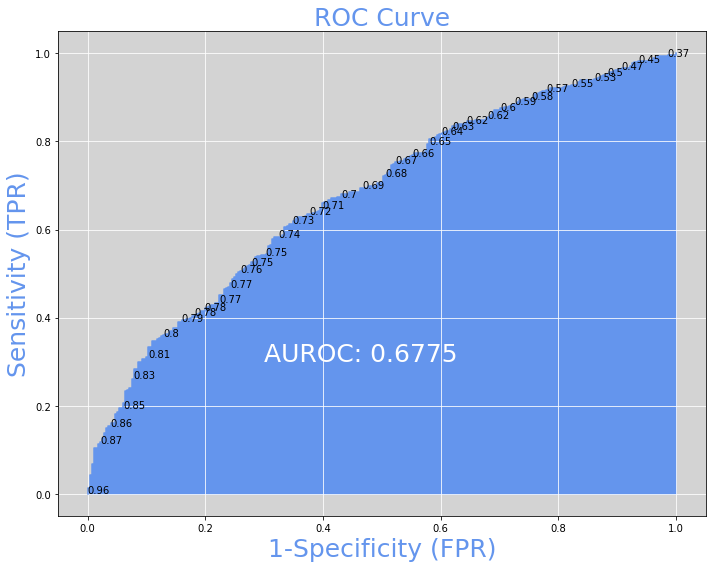

In [66]:
fpr, tpr, thresholds = metrics.roc_curve(data_mat[["y"]], 
                                         predicted_probs_logit, pos_label = 1)
plotROC(fpr, tpr, thresholds)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:18: MatplotlibDeprecationWarning:

Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.



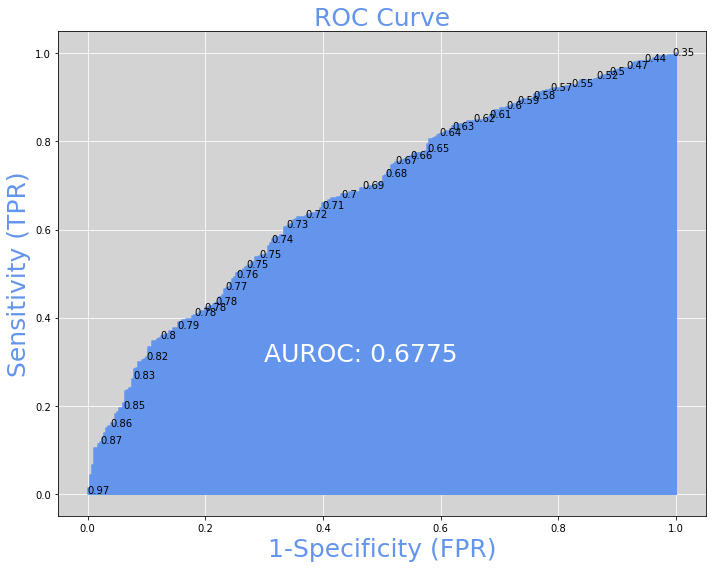

In [67]:
fpr, tpr, thresholds = metrics.roc_curve(data_mat[["y"]], 
                                         predicted_probs_probit, pos_label = 1)
plotROC(fpr, tpr, thresholds)